In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fuel Optimization: Speed vs. Cost (including wind impact)

**Goal:** Build a simple mathematical model + simulation to estimate fuel consumption and find an "optimal" driving speed under different wind conditions.

**Author:** Alexander

**Date:** 2026-

## 1. Introduction

Fuel consumption optimization is an important practical problem in transportation engineering. The relationship between vehicle speed and fuel consumption is non-linear and strongly influenced by physical forces acting on the vehicle.

This project develops a mathematical model describing fuel consumption as a function of vehicle speed. The model incorporates the two dominant resistive forces:
- Aerodynamic drag
- Rolling resistance


The objective is to:
- Determine how fuel consumption depends on speed
- Identify the speed that minimizes fuel usage
- Analyze how atmospheric conditions (e.g., wind) shift the optimal speed
- Evaluate the robustness of the model under parameter variations
- Compare model predictions with real-world fuel consumption data

The approach follows an iterative modeling strategy, starting from a simplified baseline model and progressively increasing complexity.

## 2. Problem formulation

We consider a passenger vehicle moving at constant speed on a flat road.

Assumptions:
1. The road is horizontal (no slope)
2. The vehicle travels at constant speed
3. Acceleration effects are ignored
4. Engine efficiency is assumed constant
5. Two resistive forces are considered
   - Aerodynamic drag
   - Rolling resistance

Aim to compute:
- Total resistive force as a function of speed
- Required mechanical power
- Fuel consumption per unit distance

## 3. Mathematical Model - Version 1

### Aerodynamic Drag
$$ F_d = \frac{1}{2} \rho C_d A v_{\text{rel}}^2 $$

Where:
- $ \rho $ = air density
- $ C_d $ = drag coefficient
- $ A $ = frontal area
- $ v_{\text{rel}} $ = relative air speed

<br>

#### Relative air velocity definition
$$ v_{\text{rel}} = v_{\text{car}} - v_{\text{wind}} $$

Where:
- $ v_{\text{wind}} > 0 \rightarrow $ tailwind
- $ v_{\text{wind}} < 0 \rightarrow $ headwind

<br>

### Rolling Resistance
$$ F_r = C_rmg $$

Where:
- $ C_r $ = rolling resistance coefficient
- $ m $ = vehicle mass
- $ g $ = gravitational acceleration

<br>

### Total Resistive Force
$$ F_{\text{total}} = F_d + F_r $$

<br>

### Required Power
$$ P = F_{\text{total}} \cdot v $$

<br>

### Fuel Consumption Approximation
Fuel consumption per distance:
$$ \text{Fuel per meter} \propto \frac{P}{v} $$

Since: $ \frac{P}{v} = F_{\text{total}} $

So fuel per distance is proportional to total resistive force.

## 4. Implementation (Version 1)

In [2]:
# Physical constants
rho = 1.225    # air density (kg/m^3)
Cd = 0.29      # drag coefficient (typical passenger car)
A = 2.2        # frontal area (m^2)
Cr = 0.015     # rolling resistance coefficient
m = 1500       # vehicle mass (kg)
g = 9.81       # gravity (m/s^2

# Speed range
v_kmh = np.linspace(10, 160, 200)
v = v_kmh / 3.6   # convert to m/s

# Forces
F_drag = 0.5 * rho * Cd * A * v**2
F_roll = Cr * m * g
F_total = F_drag + F_roll

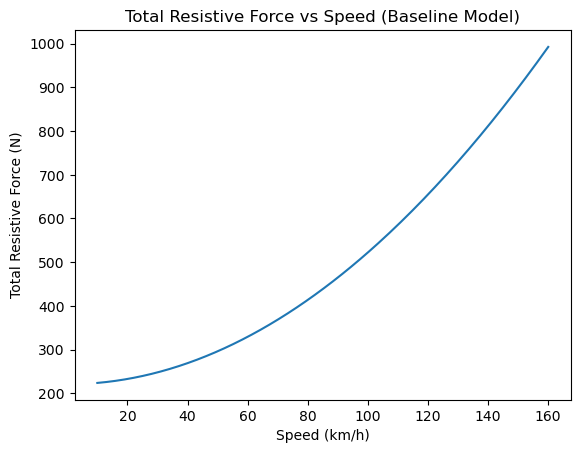

In [3]:
plt.plot(v_kmh, F_total)
plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed (Baseline Model)")
plt.show()

## 5. Mathematical Model - Version 2 (Wind conditions)

In Version 1 we already defined the general relative air speed:
$$ v_{rel} = v_{car} - v_{wind} $$
<br>
However, the baseline results in Version 1 correspond to the **no-wind case** $(v_{wind}=0)$, therefore:
$$ v_{rel} = v_{car}$$

In Version 2 we extend the model by testing non-zero wind scenarios $(v_{wind}\neq 0)$ and comparing headwind vs. tailwind effects.

### Test with moderate wind

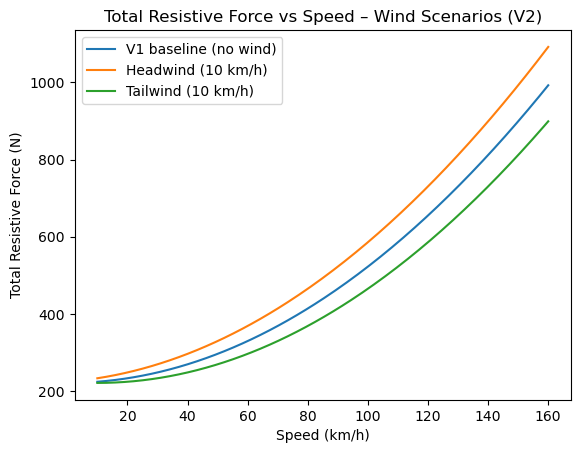

In [13]:
wind_kmh = {
    "Headwind (10 km/h)": -10,
    "Tailwind (10 km/h)": 10,
}

plt.plot(v_kmh, F_total, label="V1 baseline (no wind)")

for label, w_kmh in wind_kmh.items():
    v_wind = w_kmh / 3.6  # m/s
    v_rel = v - v_wind
    F_drag_wind = 0.5 * rho * Cd * A * (v_rel ** 2)
    F_total_wind = F_drag_wind + F_roll
    plt.plot(v_kmh, F_total_wind, label=label)

plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed – Wind Scenarios (V2)")
plt.legend()
plt.show()

### Test with strong wind

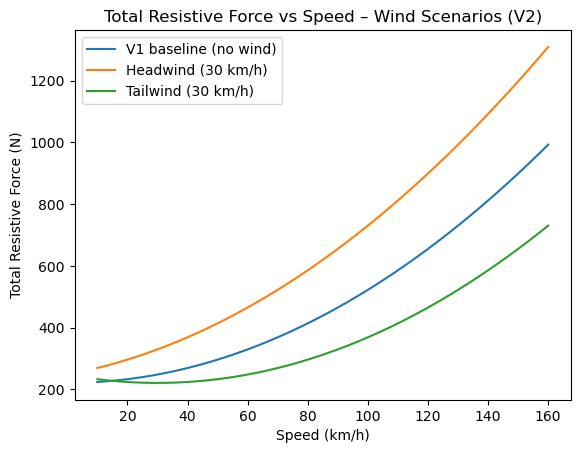

In [8]:
wind_kmh = {
    "Headwind (30 km/h)": -30,
    "Tailwind (30 km/h)": 30,
}

plt.plot(v_kmh, F_total, label="V1 baseline (no wind)")

for label, w_kmh in wind_kmh.items():
    v_wind = w_kmh / 3.6  # m/s
    v_rel = v - v_wind
    F_drag_wind = 0.5 * rho * Cd * A * (v_rel ** 2)
    F_total_wind = F_drag_wind + F_roll
    plt.plot(v_kmh, F_total_wind, label=label)

plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed – Wind Scenarios (V2)")
plt.legend()
plt.show()

### Observation: Effect of Wind at Different Speeds

The plot shows that wind noticeably changes the resistive force experienced by the vehicle.

At low speeds the difference between the curves is relatively small. However, as speed increases, the gap between the headwind and tailwind scenarios becomes much larger.

This occurs because aerodynamic drag depends on the square of the relative air velocity:

$F_d = \frac{1}{2}\rho C_d A v_{rel}^2$

When a headwind is present, the relative air speed increases, which causes drag to grow rapidly.  
When a tailwind is present, the relative air speed decreases, reducing aerodynamic drag.

As a result:

- **Headwind (30 km/h)** produces the highest resistive force.
- **No wind** produces intermediate values.
- **Tailwind (30 km/h)** produces the lowest resistive force.

The effect becomes especially visible at highway speeds, where aerodynamic drag dominates the total resistive force.

### Extreme Wind Scenario (Illustrative Example)

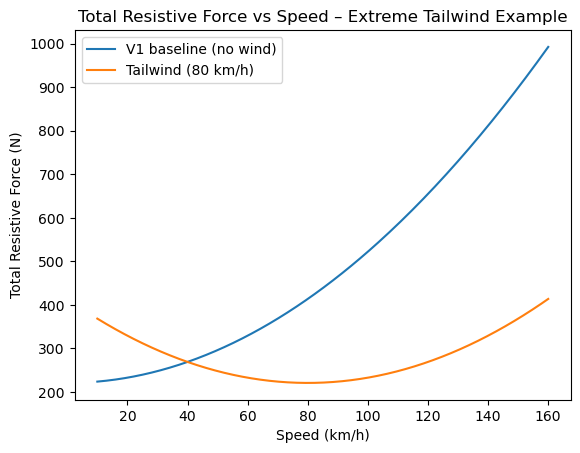

In [14]:
v_wind_kmh = 80

plt.plot(v_kmh, F_total, label="V1 baseline (no wind)")

v_wind = v_wind_kmh / 3.6
v_rel = v - v_wind
F_drag_wind = 0.5 * rho * Cd * A * (v_rel ** 2)
F_total_wind = F_drag_wind + F_roll

plt.plot(v_kmh, F_total_wind, label="Tailwind (80 km/h)")

plt.xlabel("Speed (km/h)")
plt.ylabel("Total Resistive Force (N)")
plt.title("Total Resistive Force vs Speed – Extreme Tailwind Example")
plt.legend()
plt.show()